In [1]:
%reload_ext autoreload
%autoreload 2

import os
import sys

import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

import numpy as np
from scipy import stats
import arviz as az
import healpy as hp
import corner
import pickle
import logging
from tqdm import tqdm
import json

os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"
print(jax.devices())

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file("../notebooks/matplotlibrc")

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[gpu(id=0)]


In [2]:
sys.path.append("..")
from models.np_model import NPModel
from utils.multi_corner import multi_corner
from utils.validation import find_hdi_prob, roc_finite_sample_band

## 1. Fit

In [4]:
pmodel = NPModel(
    non_poissonian=False,
    l_max=0,
    vary_gamma=True,
    bulge_hybrid=True,
    ps_cat="3fgl",
    nside=128,
)

save_dir = "../outputs/poiss_sim/run_230816_pm"

In [ ]:
rng_key = jax.random.PRNGKey(42)

for i in range(0, 30):
    print(i)
    rng_key, key = jax.random.split(rng_key)
    counts = jnp.array(np.load(f"{save_dir}/counts_{i}.npy"), dtype=jnp.int32)
    svi_results = pmodel.fit_svi(
        rng_key=key,
        n_steps=2000,
        guide="iaf",
        lr=3e-5,
        num_particles=16,
        data=jnp.array(counts),
    )
    pickle.dump(svi_results, open(f"{save_dir}/svi_results_{i}.p", 'wb'))
    rng_key, key = jax.random.split(rng_key)
    samples = pmodel.get_svi_samples(
        rng_key=key,
        num_samples=50000,
    )
    pickle.dump(samples, open(f"{save_dir}/samples_{i}.p", 'wb'))

### 1.1. View

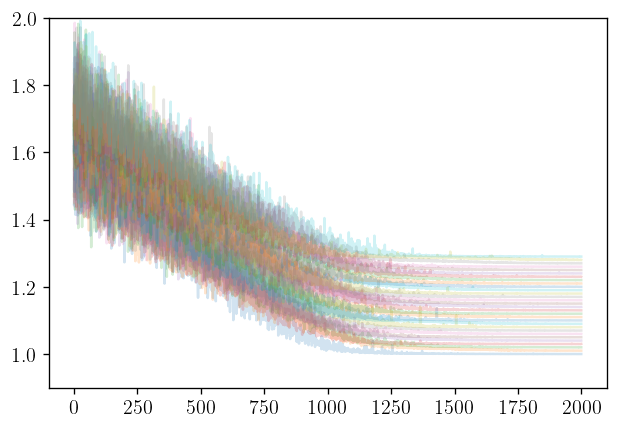

In [70]:
fig, ax = plt.subplots()
for i in range(30):
    svi_results = pickle.load(open(f"{save_dir}/svi_results_{i}.p", 'rb'))
    ax.plot(svi_results.losses/svi_results.losses[-1]+i*0.01, alpha=0.2)
ax.set(ylim=(0.9, 2));

In [50]:
samples = pickle.load(open(f"{save_dir}/samples_0.p", 'rb'))
samples.keys()

dict_keys(['Alm_0', 'Alm_1', 'Alm_2', 'Alm_3', 'Alm_4', 'Alm_5', 'S_bub', 'S_dif', 'S_gce', 'S_ics', 'S_iso', 'S_psc', 'f_bulge_poiss', 'gamma_poiss', 'theta_p_mcdermott2022', 'theta_p_mcdermott2022_bbp', 'theta_p_mcdermott2022_x', 'theta_p_macias2019', 'theta_p_coleman2019', 'theta_ics_ModelO', 'theta_ics_ModelA', 'theta_ics_ModelF', 'theta_pib_ModelO', 'theta_pib_ModelA', 'theta_pib_ModelF'])

In [52]:
truth_dict = np.load(f"{counts_dir}/truth.npy", allow_pickle=True).item()
truth_dict = pmodel.expand_samples(truth_dict)
truth_dict.keys()

dict_keys(['theta_pib_ModelO', 'theta_pib_ModelA', 'theta_pib_ModelF', 'theta_ics_ModelO', 'theta_ics_ModelA', 'theta_ics_ModelF', 'S_iso', 'S_bub', 'S_psc', 'S_dif', 'S_ics', 'S_dsk', 'zs', 'C', 'S_gce', 'gamma_poiss', 'f_bulge_poiss', 'theta_p_mcdermott2022', 'theta_p_mcdermott2022_bbp', 'theta_p_mcdermott2022_x', 'theta_p_macias2019', 'theta_p_coleman2019'])

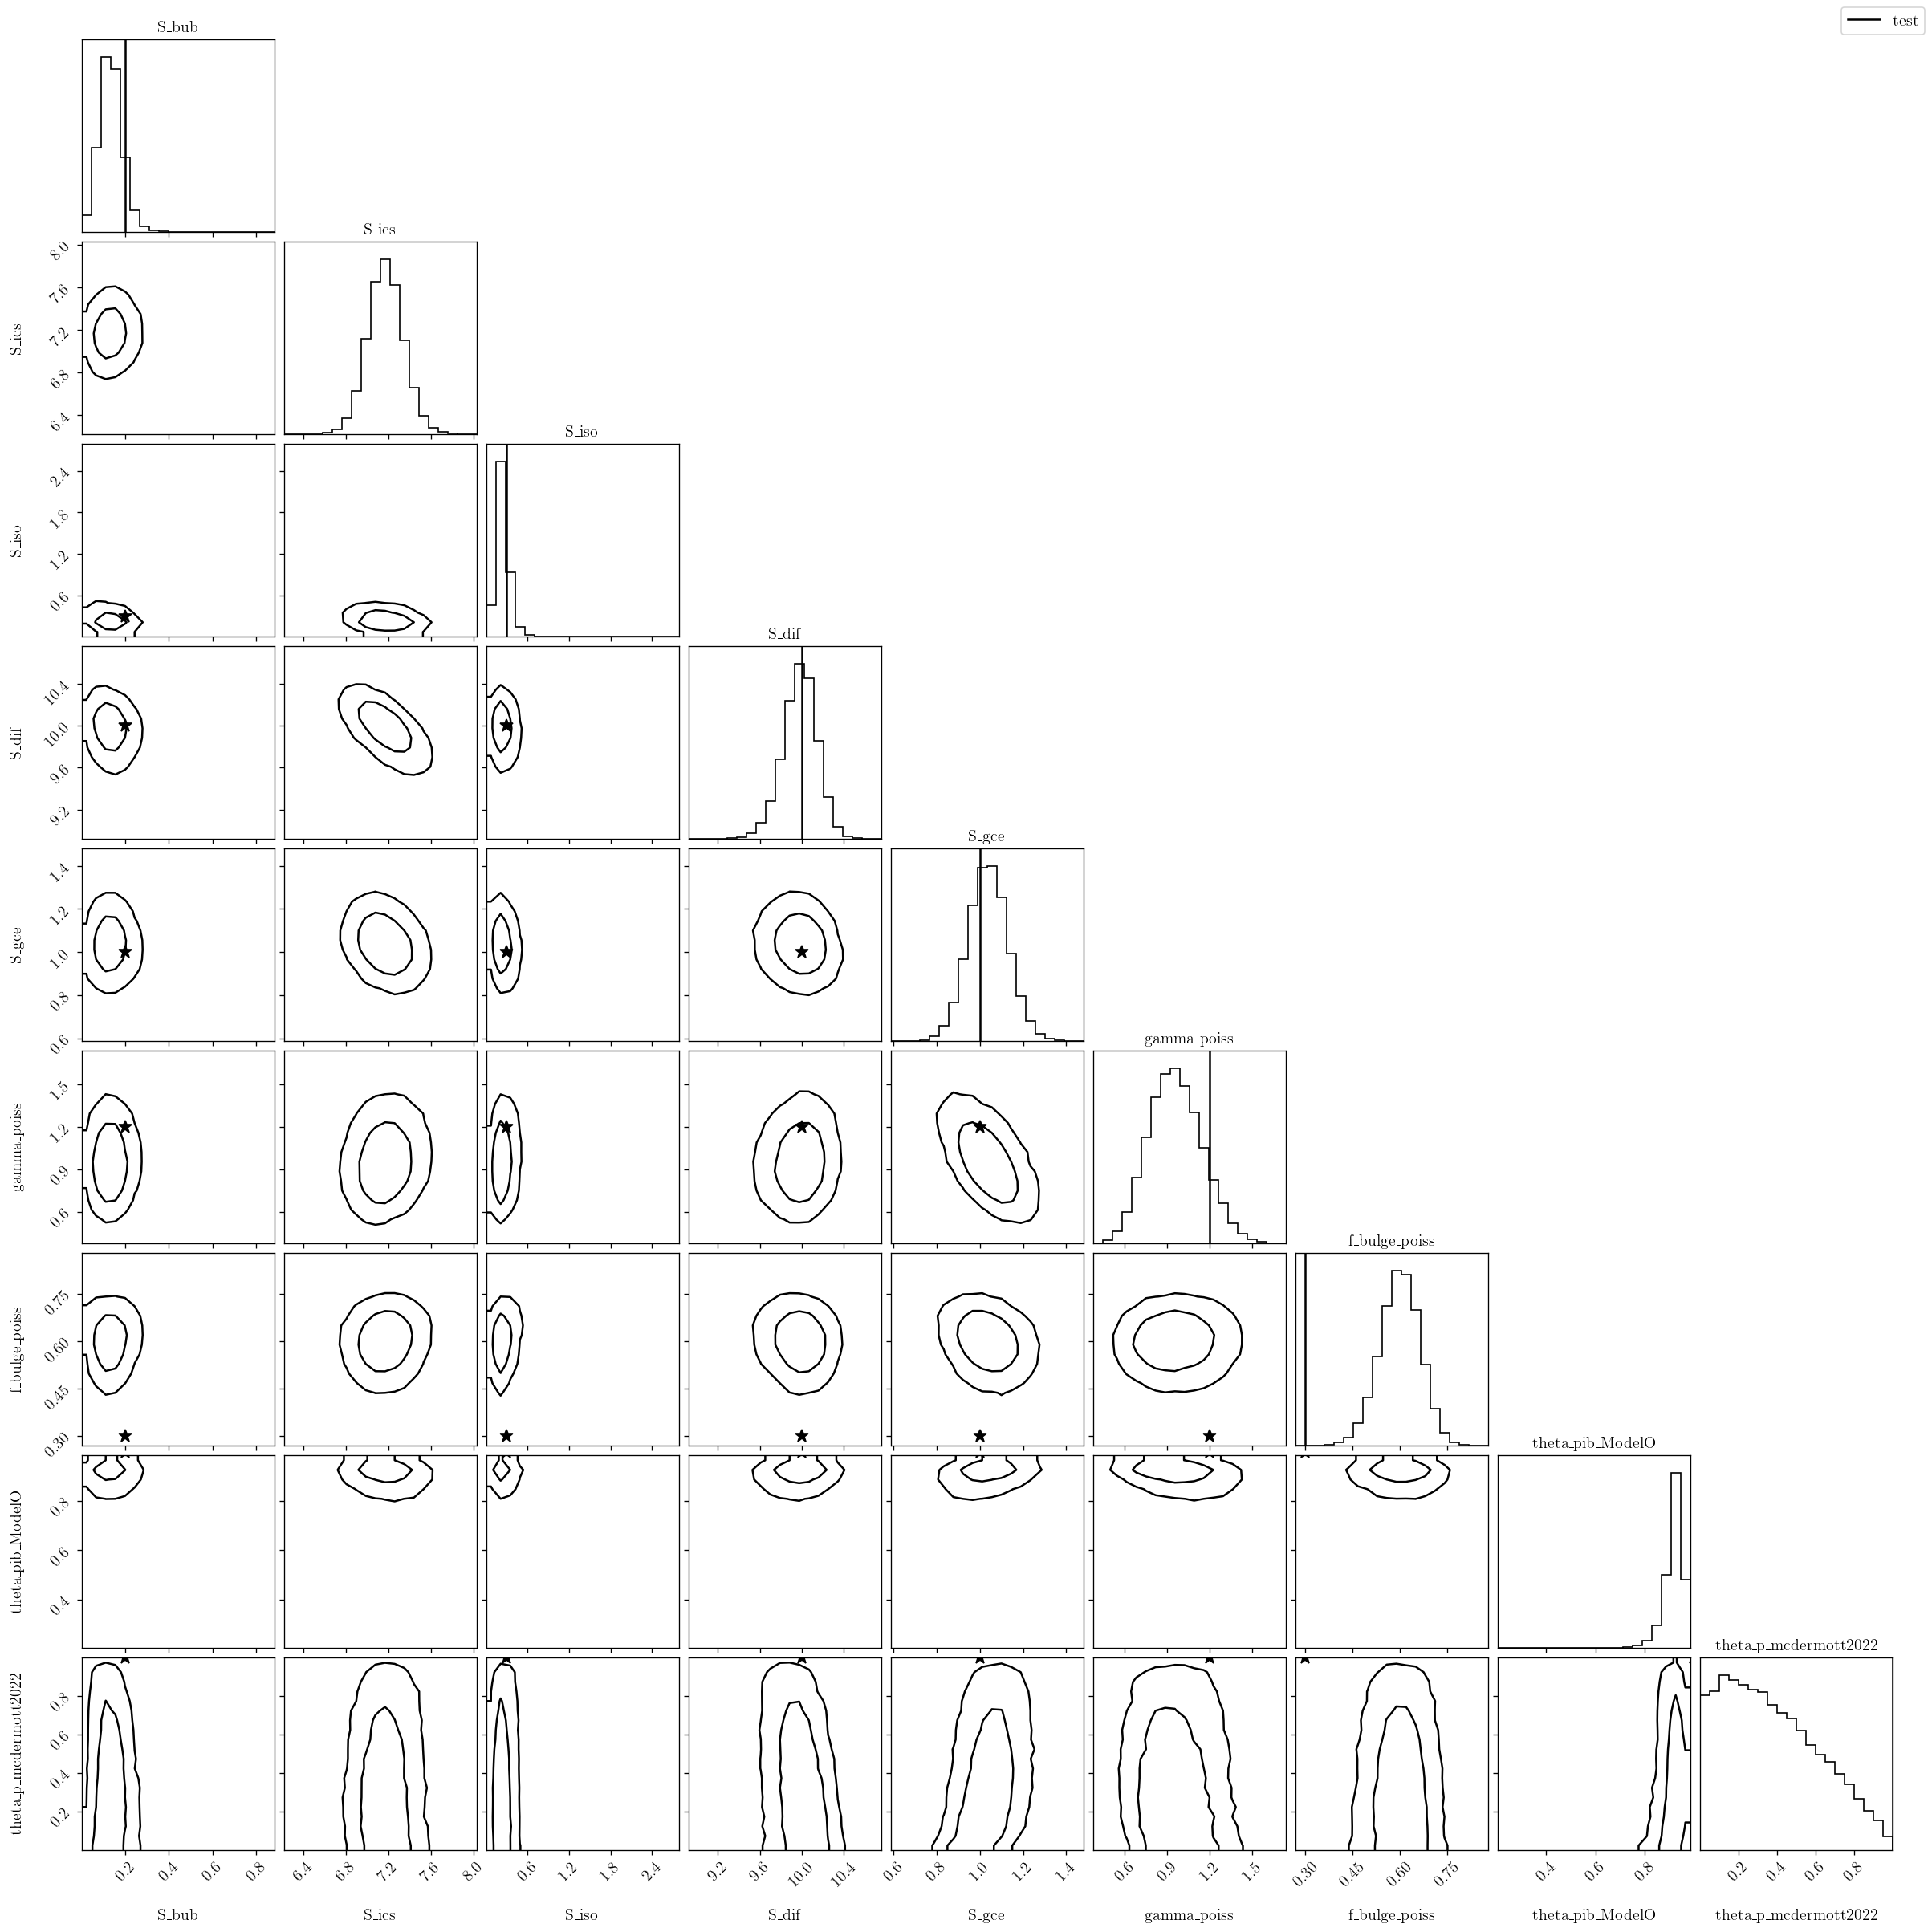

In [53]:
samples_dict = {
    '' : samples
}
colors_dict = {
    '' : 'k'
}
labels_dict = {
    '' : 'test'
}
plot_var_names = [
    'S_bub', 'S_ics', 'S_iso', 'S_dif',
    #'C', 'zs',
    'S_gce', 'gamma_poiss', 'f_bulge_poiss',
    'theta_pib_ModelO', 'theta_p_mcdermott2022'
]

logging.getLogger().setLevel(logging.ERROR)
multi_corner(
    samples_dict, plot_var_names,
    MAP=truth_dict,
    colors_dict=colors_dict, labels_dict=labels_dict,
    hist_bin_factor=1
)

## 2. Coverage test

In [5]:
run_dir = "../outputs/poiss_sim/run_230816_pm"
truth_dict = pickle.load(open(f"{run_dir}/truth.p", 'rb'))
truth_dict = pmodel.expand_samples(truth_dict)
truth_dict.keys()

dict_keys(['theta_pib_ModelO', 'theta_pib_ModelA', 'theta_pib_ModelF', 'theta_ics_ModelO', 'theta_ics_ModelA', 'theta_ics_ModelF', 'S_iso', 'S_bub', 'S_psc', 'S_pib', 'S_ics', 'S_dsk', 'zs', 'C', 'S_gce', 'gamma_poiss', 'f_bulge_poiss', 'theta_poiss_mcdermott2022', 'theta_poiss_mcdermott2022_bbp', 'theta_poiss_mcdermott2022_x', 'theta_poiss_macias2019', 'theta_poiss_coleman2019'])

### 2.1 Truth and bias

In [11]:
ks = ['S_iso', 'S_bub', 'S_psc', 'S_pib', 'S_ics',
      'S_gce', 'gamma_poiss', 'f_bulge_poiss', 'theta_pib_ModelO', 'theta_poiss_mcdermott2022']

In [12]:
def fit_mean(k):
    fit_means = []
    sample_fns = [fn for fn in os.listdir(run_dir) if fn.startswith('sample')]
    for fn in sample_fns:
        s = pickle.load(open(f"{run_dir}/{fn}", 'rb'))
        fit_means.append(np.mean(s[k]))
    return np.mean(fit_means)

def roc(k):
    m = fit_mean(k)
    ps = []
    sample_fns = [fn for fn in os.listdir(run_dir) if fn.startswith('sample')]
    for fn in sample_fns:
        s = pickle.load(open(f"{run_dir}/{fn}", 'rb'))
        samples = np.array(s[k])
        p = find_hdi_prob(samples, m, level=15)
        ps.append(p)
    ps = np.sort(ps)
    return ps

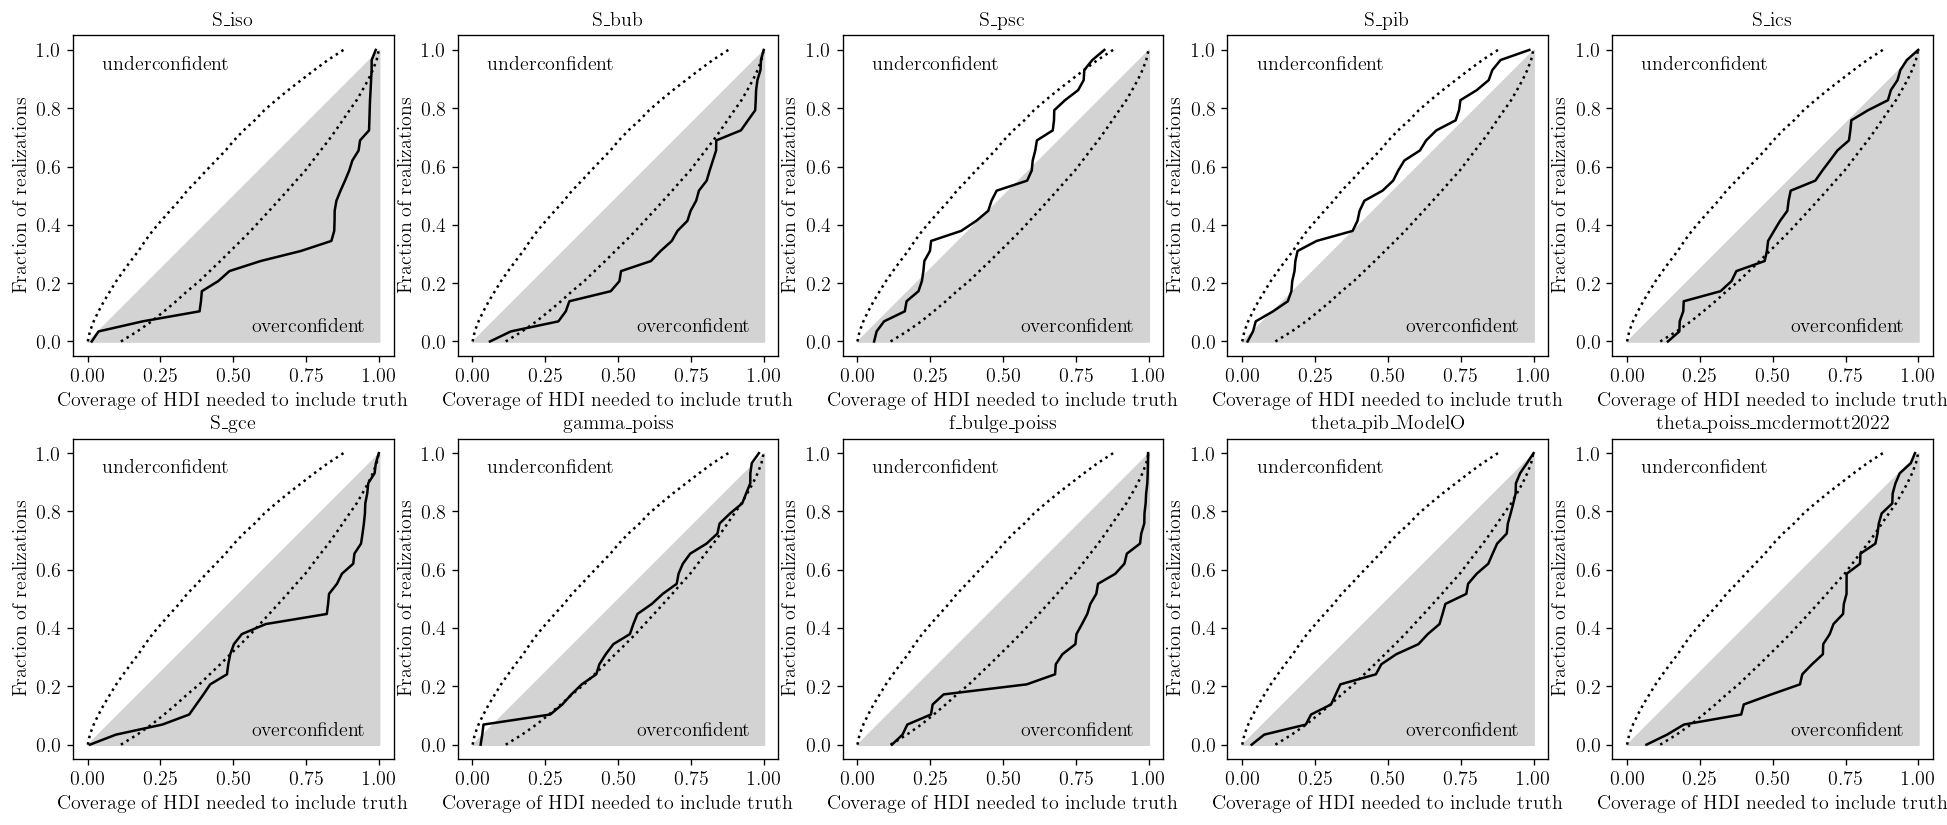

In [13]:
n_runs = 30
invcdf_lower, invcdf_upper = roc_finite_sample_band(n_runs)

fig, axs = plt.subplots(2, 5, figsize=(20, 8))

for i, k in enumerate(ks):
    ax = axs[i//5, i%5]
    ax.fill_between([0,1], [0,1], color='lightgray')
    ax.plot(roc(k), np.linspace(0, 1, n_runs), color='k', label=k)
    
    ax.plot(invcdf_upper, np.linspace(0, 1, n_runs), 'k:', label=f'{n_runs} sample 95\% containment')
    ax.plot(invcdf_lower, np.linspace(0, 1, n_runs), 'k:')

    ax.set(aspect=1)
    ax.set(xlabel='Coverage of HDI needed to include truth', ylabel='Fraction of realizations',
           title=f'{k}')
    ax.text(0.95, 0.05, 'overconfident', ha='right', va='center')
    ax.text(0.05, 0.95, 'underconfident', ha='left', va='center')

fig.savefig(f'plots/pmodel_ROC.pdf');

### 2.2 View posteriors

100%|█████████████████████████████████████████████████████████████████████████████| 100/100 [02:36<00:00,  1.56s/it]


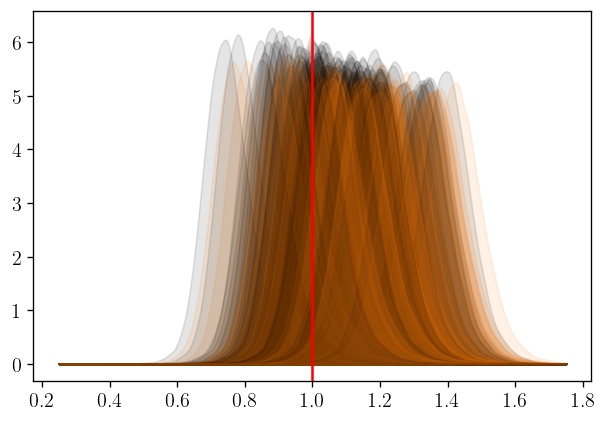

In [18]:
fig, ax = plt.subplots()

sample_fns = [fn for fn in os.listdir(run_dir) if fn.startswith('sample')]

for fn in tqdm(sample_fns):
    #sk = k if k != 'S_pib' else 'S_dif'
    s = pickle.load(open(f"{run_dir}/{fn}", 'rb'))
    samples = np.array(s['S_gce'])
    kde = stats.gaussian_kde(samples)
    val_s = np.linspace(0.25, 1.75, 1000)
    ax.fill_between(val_s, kde(val_s), color='k', alpha=0.1)
    samples = np.array(s['S_gce']) + np.array(s['Sps_gce'])
    kde = stats.gaussian_kde(samples)
    val_s = np.linspace(0.25, 1.75, 1000)
    ax.fill_between(val_s, kde(val_s), color='C1', alpha=0.1)
ax.axvline(true_val, color='red')

In [18]:
sample_fns = [fn for fn in os.listdir(run_dir) if fn.startswith('sample')]
std_s = []
for fn in tqdm(sample_fns):
    sk = k if k != 'S_pib' else 'S_dif'
    s = pickle.load(open(f"{run_dir}/{fn}", 'rb'))
    samples = np.array(s[sk])
    std_s.append(np.std(samples))
print(np.mean(std_s))

100%|█████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 61.43it/s]

0.07844684


## 3. ROC finite sample band

In [ ]:
from scipy import special

In [21]:
invcdf_arr = []
for _ in tqdm(range(10000)):
    x_sample = np.random.normal(size=100)
    p_sample = (special.erf(np.abs(x_sample)/np.sqrt(2)) - special.erf(-np.abs(x_sample)/np.sqrt(2))) / 2
    invcdf_arr.append(np.sort(p_sample))
invcdf_arr = np.array(invcdf_arr)
invcdf_upper = np.quantile(invcdf_arr, 0.975, axis=0)
invcdf_lower = np.quantile(invcdf_arr, 0.025, axis=0)

100%|██████████| 10000/10000 [00:00<00:00, 48386.47it/s]


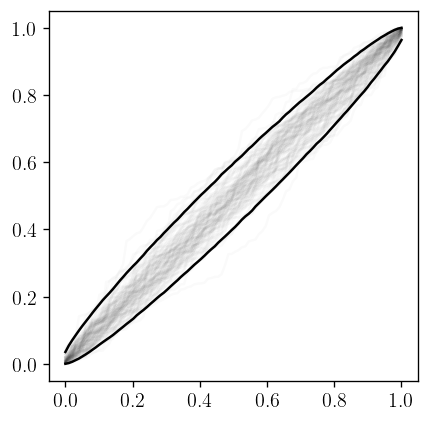

In [22]:
fig, ax = plt.subplots()
for i in range(100):
    ax.plot(np.linspace(0, 1, 100), invcdf_arr[i], 'k-', alpha=0.02)
ax.plot(np.linspace(0, 1, 100), invcdf_upper, 'k')
ax.plot(np.linspace(0, 1, 100), invcdf_lower, 'k')
ax.set_aspect('equal')